# ALS over a DTM with constant height above ground (Heidelberg)

Notebook creator: Hannah Weiser, 2025

This demo uses a digital terrain model (DTM) of Heidelberg, Germany, which will be scanned by airborne laser scanning (ALS), maintaining a constant height above ground using interpolated trajectories.

In [1]:
from pathlib import Path
import helios
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
from scipy.interpolate import CubicSpline, make_interp_spline
import rasterio as rio
from helios.platforms import Platform, load_traj_csv

In [2]:
def interpolate_waypoints(t, x, y, time_step, b_spline_degree=3):
    """ Interpolates waypoints to create a smooth trajectory using cubic splines."""

    # Generate new time points
    new_t = np.arange(t[0], t[-1] + time_step, time_step)
    fx = make_interp_spline(t, x, b_spline_degree)
    fy = make_interp_spline(t, y, b_spline_degree)
    
    # Interpolate x and y
    new_x = fx(new_t)
    new_y = fy(new_t)

    return new_t, new_x, new_y



def compute_yaw_angles(x, y):
    yaw_angles = []
    for i in range(len(x) - 1):
        dx = x[i+1] - x[i]
        dy = y[i+1] - y[i]
        yaw = np.arctan2(dx, dy)
        # Normalize yaw to be in the range [0, 2π)
        if yaw < 0:
            yaw += 2 * np.pi
        # Append the yaw angle
        yaw_angles.append(yaw)
    
    # Append the last yaw angle
    yaw_angles.append(yaw_angles[-1])
    
    return np.array(yaw_angles)



def follow_height_above_ground(x, y, height_agl, dtm_file):
    coords = np.array([x, y]).T
    with rio.open(dtm_file) as src:
        z_vals = [z[0] + height_agl for z in src.sample(coords)]

    return np.array(z_vals)

## Creating the virtual scene

In [3]:
# load geotiff
dtm_file = "../data/sceneparts/tiff/dem_hd.tif"
dtm = helios.ScenePart.from_tiff(dtm_file)
# scene
scene = helios.StaticScene(scene_parts=[dtm])

## Scanner

In [4]:
scanner = helios.scanner_from_name("leica_als50")

## Survey Route

In [5]:
waypoints = np.array([
    [477280.4, 5472582.6],
    [480531.0, 5472590.9],
    [480553.9, 5473285.3],
    [477304.6, 5473277.0],
    [477313.5, 5473863.9],
    [480567.7, 5473888.6]
])

# compute time assuming constant speed
speed_m_s = 250
distances_between_waypoints = np.linalg.norm(np.diff(waypoints, axis=0), axis=1)
times = [0]
for distance in distances_between_waypoints:
    times.append(times[-1] + distance / speed_m_s)

In [6]:
# interpolate waypoints to create a trajectory
time_step = 0.2  # s
height_agl = 1000  # m
t, x, y = interpolate_waypoints(times, waypoints[:, 0], waypoints[:, 1], time_step=time_step, b_spline_degree=1)

z = follow_height_above_ground(x, y, height_agl, dtm_file)

roll = np.zeros(len(x))  # Assuming roll is zero for simplicity
pitch = np.zeros(len(x))  # Assuming pitch is zero for simplicity
yaw = compute_yaw_angles(x, y)
waypoints_final = np.zeros(len(x), dtype={'names':('t', 'roll', 'pitch', 'yaw', 'x', 'y', 'z'),
                                          'formats':('f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8')})
waypoints_final['x'] = x
waypoints_final['y'] = y
waypoints_final['z'] = z
waypoints_final['t'] = t
waypoints_final['roll'] = roll
waypoints_final['pitch']= pitch
waypoints_final['yaw'] = yaw

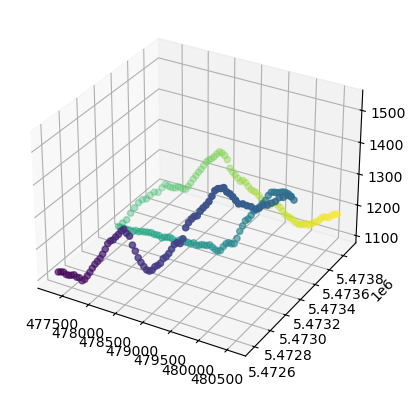

In [7]:
# plot trajectory
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(waypoints_final['x'], waypoints_final['y'], waypoints_final['z'], 'ro-', label='Trajectory', c=waypoints_final['t'])
plt.show()

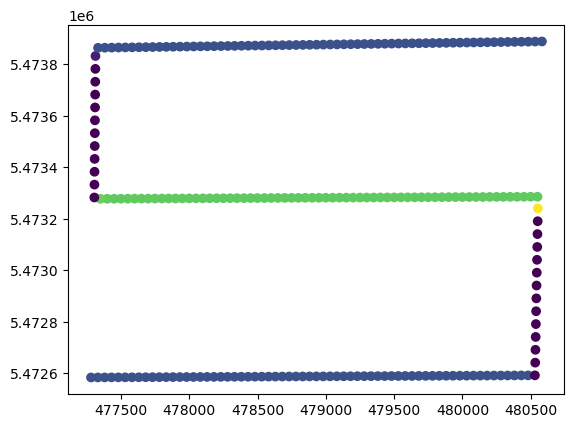

In [8]:
# plot from above coloured by yaw
plt.scatter(waypoints_final['x'], waypoints_final['y'], c=waypoints_final['yaw'])
plt.show()

## Platfrom and scanner settings

In [10]:
platform = Platform.load_interpolate_platform(
    trajectory=waypoints_final,
    platform_file="data/platforms.xml",
    platform_id="sr22",
    interpolation_method="CANONICAL",
    sync_gps_time=True)

In [11]:
scanner_settings = helios.ScannerSettings(pulse_frequency=83_000 * helios.units.Hz,
                                          scan_frequency=50 * helios.units.Hz,
                                          scan_angle=30 * helios.units.deg,
                                          head_rotation="0 deg/s",
                                          trajectory_time_interval=0.06 * helios.units.s
                                         )

In [12]:
survey = helios.Survey(scanner=scanner, platform=platform, scene=scene)
for i in range(len(times)-1):
    print(f"Adding leg {i} from {times[i]} to {times[i+1]}")
    trajectory_settings_leg = helios.platforms.TrajectorySettings(start_time=times[i], end_time=times[i+1], teleport_to_start=True)
    survey.add_leg(scanner_settings=scanner_settings, trajectory_settings=trajectory_settings_leg)

Adding leg 0 from 0 to 13.00244238595187
Adding leg 1 from 13.00244238595187 to 15.78155237297786
Adding leg 2 from 15.78155237297786 to 28.778794775887977
Adding leg 3 from 28.778794775887977 to 31.126664687106867
Adding leg 4 from 31.126664687106867 to 44.14383963714886


## Running the survey

In [14]:
points, trajectory = survey.run(verbosity=helios.LogVerbosity.VERBOSE)

Legs:   0%|          | 0/15 [00:00<?, ?leg/s]

Current leg time: 0.00s [00:00, ?s/s]

In [15]:
points["position"]

array([[4.77281935e+05, 5.47314481e+06, 1.14609067e+02],
       [4.77281891e+05, 5.47316519e+06, 1.10629962e+02],
       [4.77281935e+05, 5.47314350e+06, 1.14881987e+02],
       ...,
       [4.80569106e+05, 5.47408873e+06, 1.18606641e+02],
       [4.80569121e+05, 5.47409025e+06, 1.18371782e+02],
       [4.80569179e+05, 5.47409631e+06, 1.17670989e+02]],
      shape=(3663937, 3))

In [16]:
trajectory["position"]

array([[4.77280403e+05, 5.47258260e+06, 1.11900018e+03],
       [4.77280406e+05, 5.47258260e+06, 1.11900036e+03],
       [4.77295406e+05, 5.47258264e+06, 1.11990036e+03],
       ...,
       [4.80523420e+05, 5.47388826e+06, 1.17600139e+03],
       [4.80538419e+05, 5.47388838e+06, 1.17740069e+03],
       [4.80553419e+05, 5.47388849e+06, 1.17830069e+03]], shape=(739, 3))

## Visualizing the results

Now we can display a couple of 2D plots of the simulated point cloud.

In [17]:
print(np.unique(points["point_source_id"]))

[ 1  4  7 10 13]


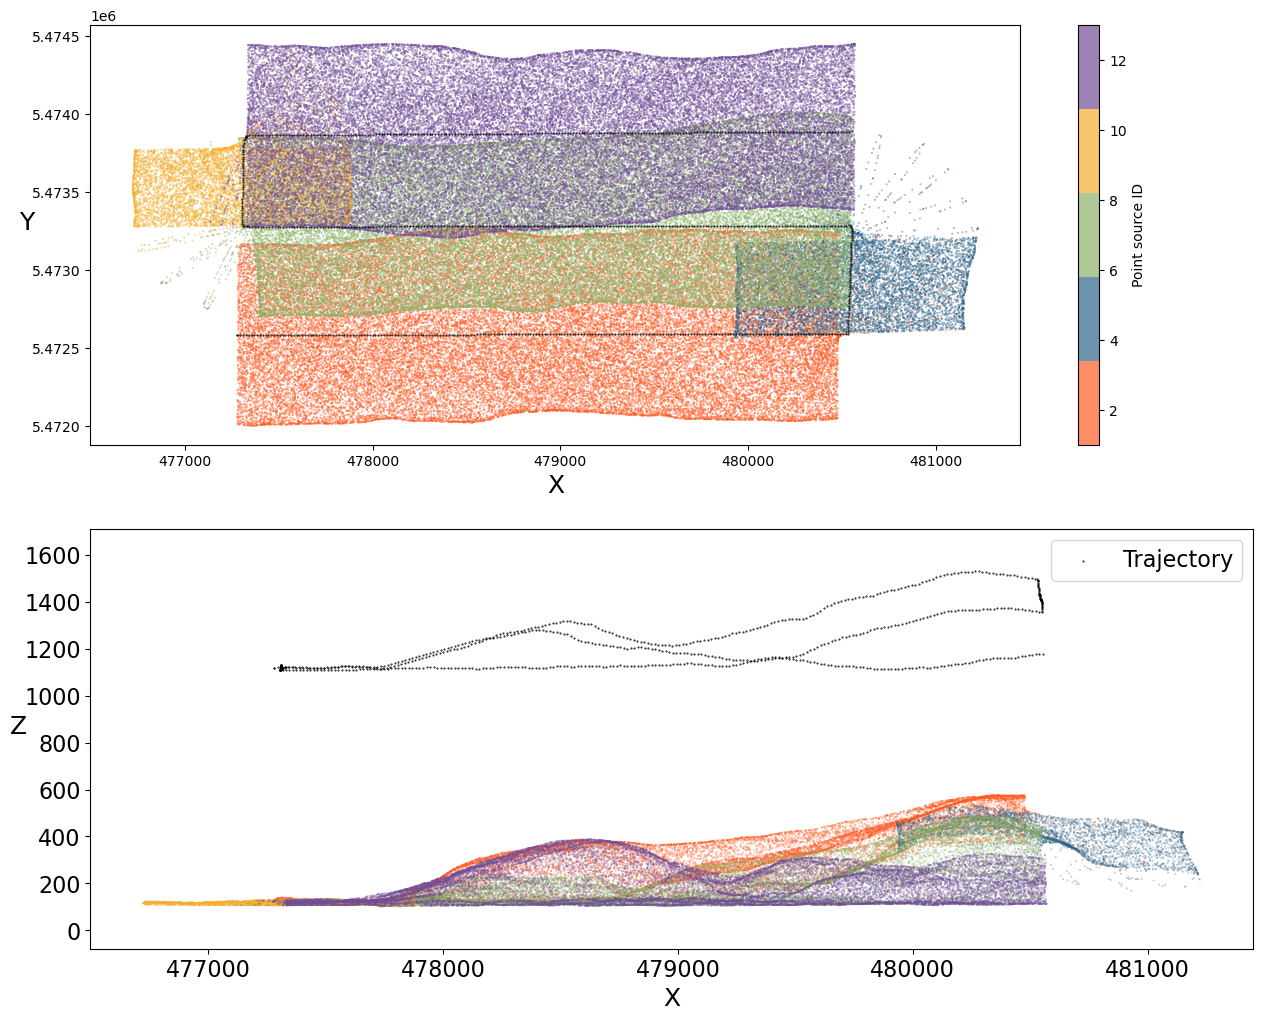

In [24]:
# two subplots
fig, (ax1, ax2) = plt.subplots(2, figsize=(15, 12))
pos = points["position"]
traj = trajectory["position"]

N = 5
colors = ["#FE5D26", "#33658A", "#8CB369", "#F6AE2D", "#724E99"]  # 5 distinct colors
rgba_colors = [mcolors.to_rgba(c) for c in colors]
cmap = mcolors.ListedColormap(rgba_colors, name="custom")  # discrete colormap with 3 colors

# view from above, colored by strip, including trajectory - for faster display, show only every 25th measurement
sc = ax1.scatter(
    pos[::25, 0], pos[::25, 1], s=0.1, alpha=0.7, c=points["point_source_id"][::25], cmap=cmap,
    # vmin=-0.5, vmax=N - 0.5
)
ax1.scatter(traj[:, 0], traj[:, 1], s=0.2, label="Trajectory", color="black")
ax1.set_xlabel("X", fontsize=18)
ax1.set_ylabel("Y", fontsize=18, rotation=0)

plt.colorbar(sc, label="Point source ID")

# use only every 50th measurement for better display
ax2.scatter(
    pos[::50, 0], pos[::50, 2], alpha=0.7, s=0.05, c=points["point_source_id"][::50], cmap=cmap,
    # vmin=-0.5, vmax=N - 0.5
)  # select X and Z coordinates
ax2.scatter(traj[:, 0], traj[:, 2], s=0.2, label="Trajectory", color="black")
ax2.tick_params(labelsize=16)
ax2.set_xlabel("X", fontsize=18)
ax2.set_ylabel("Z", fontsize=18, rotation=0)
ax2.legend(fontsize=16)

plt.axis("equal")
plt.show()